In [304]:
# imports
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Exploratory analysis
diamonds = pd.read_csv("../data/diamonds.csv", index_col=0)

diamonds = diamonds.dropna()
diamonds.head()

KeyError: 'size'

In [ ]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


In [ ]:
# Drop zero values
(diamonds[["x", "y", "z"]] == 0).sum()
i = diamonds[(diamonds[["x", "y", "z"]] == 0).any(axis=1)].index
diamonds = diamonds.drop(i)
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53920 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53920 non-null  float64
 1   cut      53920 non-null  object 
 2   color    53920 non-null  object 
 3   clarity  53920 non-null  object 
 4   depth    53920 non-null  float64
 5   table    53920 non-null  float64
 6   price    53920 non-null  int64  
 7   x        53920 non-null  float64
 8   y        53920 non-null  float64
 9   z        53920 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


In [ ]:
# Make new column x*y*z - size
diamonds["size"] = diamonds["x"] * diamonds["y"] * diamonds["z"]

# Get out high leverage points
diamonds = diamonds[diamonds["size"] < 1000]

diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,size
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250


In [ ]:
diamonds.describe()

,carat,depth,table,price,x,y,z,size
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046,129.897567
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530,78.219789
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,31.707984
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000,65.189759
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,114.840180
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000,170.846415
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,3840.598060


In [ ]:
# Univariate model
n = len(diamonds)
p = 1

x = diamonds["size"]
y = diamonds["price"]

x_mean = x.mean()
y_mean = y.mean()

beta_1 = ((x - x_mean)*(y - y_mean)).sum() / ((x - x_mean)**2).sum()
beta_0 = y_mean - beta_1 * x_mean

model = beta_0 + beta_1 * x

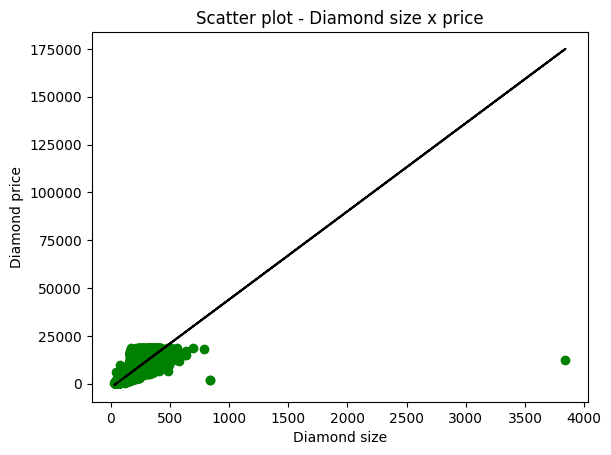

In [ ]:
# Linear regression graph
plt.scatter(x, y, c="green")
plt.plot(x, model, color="black", label="Regression line")
plt.xlabel("Diamond size")
plt.ylabel("Diamond price")
plt.title("Scatter plot - Diamond size x price")
plt.show()

In [ ]:
# Residual
residual = (y - model)**2
RSS = residual.sum()
RMSE = math.sqrt(RSS/n)
MAE = 1/n * ((y - model).abs()).sum()

# Leverage point 
hi = 1/n + ((x - x_mean)**2)/((x-x_mean)**2).sum()
hi_vs = (2*(p+1))/n

print("Basic information")
print(f"RSS: {RSS}")
print(f"RMSE: {RMSE}")
print(f"MAE: {MAE}")

print()
print("Leverage points")
print(f"hi_vs: {hi_vs}")
print(f"Number of point above limit: {(hi > hi_vs).sum()}")

Basic information
RSS: 156292484765.7001
RMSE: 1702.527384482504
MAE: 977.5283146117077

Leverage points
hi_vs: 7.41839762611276e-05
Number of point above limit: 3132
